# Phase 7: Dimensionality Reduction & Clustering
## Project Pivot: Game-Centric Representation
This notebook implements the reduction of the Master Table features and the semantic embeddings to identify **Bridge Titles** using clustering techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap
import os

# Settings
sns.set(style="whitegrid")
os.makedirs('../reports/figures', exist_ok=True)

C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Load Enriched Master Table & Embeddings

In [2]:
df = pd.read_parquet('../data/processed/master_games_ml_enriched.parquet')
embeddings = np.load('../data/processed/game_embeddings.npy')

print(f"Master Table Shape: {df.shape}")
print(f"Embeddings Shape: {embeddings.shape}")

Master Table Shape: (50872, 24)
Embeddings Shape: (50872, 384)


### 2. Feature Selection & Scaling
We select numerical metrics (hours, ratings, sentiment) and combine them with the semantic embeddings.

In [3]:
numerical_cols = [
    'hours_mean', 'hours_median', 'hours_std', 
    'rec_ratio', 'review_count', 'fan_avg_products', 
    'hater_avg_products', 'sentiment_score'
]

X_num = df[numerical_cols].values

# Scale numerical features
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Combine with embeddings (we might want to weight them differently)
# For now, we concatenate them
X_combined = np.hstack([X_num_scaled, embeddings])

print(f"Combined Feature Matrix Shape: {X_combined.shape}")

Combined Feature Matrix Shape: (50872, 392)


### 3. PCA: Dimensionality Reduction & Justification
The professor requested a justification for the number of components.

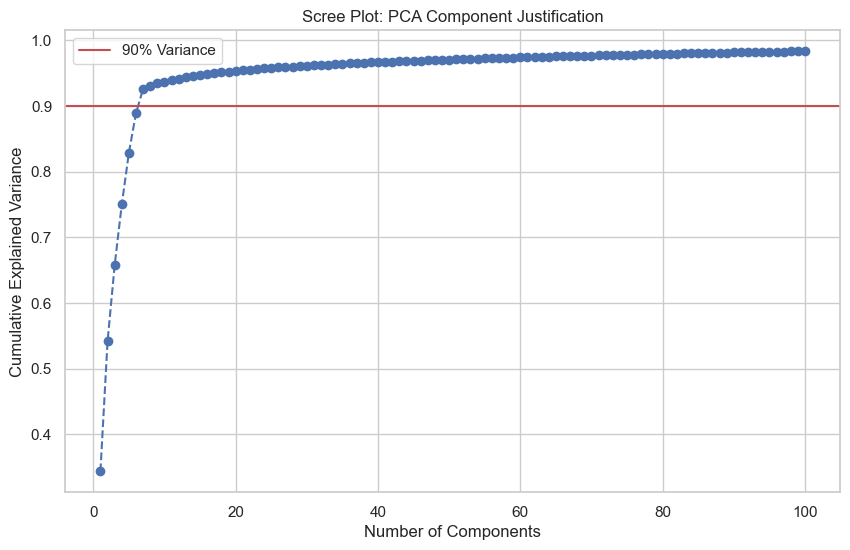

Number of components to explain 90% variance: 7


In [4]:
pca = PCA(n_components=100) # Analyze first 100 components
pca.fit(X_combined)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 101), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot: PCA Component Justification')
plt.legend()
plt.savefig('../reports/figures/pca_justification.png')
plt.show()

n_comp_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Number of components to explain 90% variance: {n_comp_90}")

### 4. Clustering (K-Means)
We use the reduced PCA space for stable clustering.

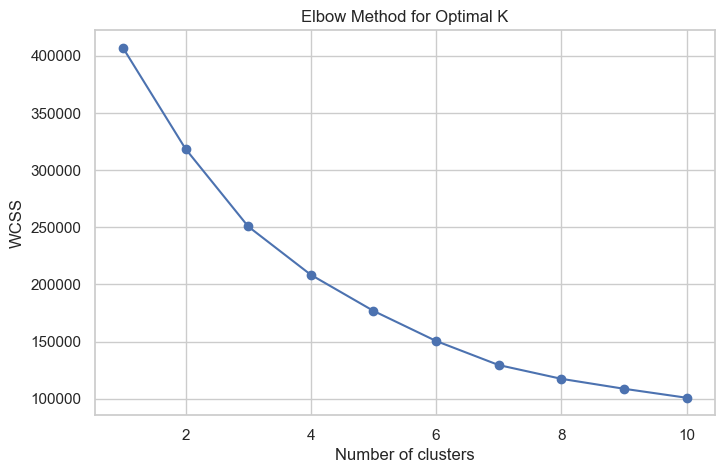

In [5]:
# Reducing to the optimized number of components
X_pca = PCA(n_components=n_comp_90).fit_transform(X_combined)

# Finding optimal K (Elbow Method)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.savefig('../reports/figures/kmeans_elbow.png')
plt.show()

### 5. Final Visualization with UMAP
We assign clusters and project into 2D.

C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


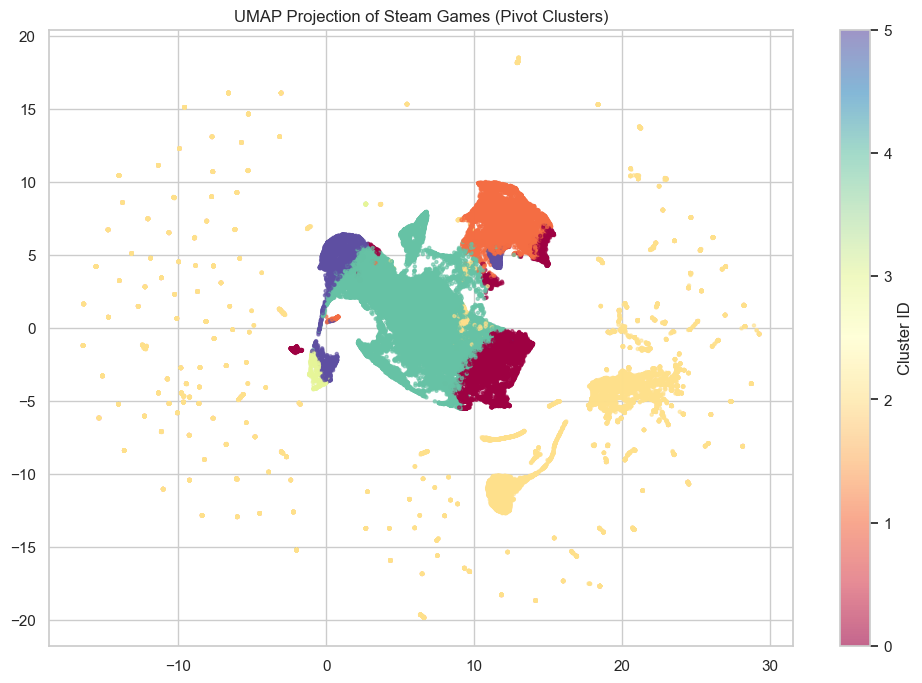

In [6]:
# Assuming k=6 based on elbow (adjust after running)
k_optimal = 6
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(X_pca)

# UMAP for 2D visualization
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_2d = reducer.fit_transform(X_pca)

df['umap_x'] = embedding_2d[:, 0]
df['umap_y'] = embedding_2d[:, 1]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['umap_x'], df['umap_y'], c=df['cluster'], cmap='Spectral', s=5, alpha=0.6)
plt.colorbar(scatter, label='Cluster ID')
plt.title('UMAP Projection of Steam Games (Pivot Clusters)')
plt.savefig('../reports/figures/umap_pivot_clusters.png')
plt.show()

### 6. Identifying Bridge Titles
Games with high proximity to multiple cluster centroids.

In [7]:
# Save final result with clusters
#df.to_parquet('../data/processed/master_games_clustered.parquet', index=False)
#print("Clustered data saved to: ../data/processed/master_games_clustered.parquet")

# Sample bridge analysis: games in cluster boundaries
df[['app_id', 'title', 'cluster', 'umap_x', 'umap_y']].head(10)

,app_id,title,cluster,umap_x,umap_y
0,13500,Prince of Persia: Warrior Within™,4,3.067626,2.545390
1,22364,BRINK: Agents of Change,2,-5.731082,12.719981
2,113020,Monaco: What's Yours Is Mine,4,1.847761,2.564430
3,226560,Escape Dead Island,4,6.529541,0.231600
4,249050,Dungeon of the ENDLESS™,4,0.985556,3.487453
5,250180,METAL SLUG 3,4,4.521411,2.282931
6,253980,Enclave,4,4.772274,2.550741
7,271850,Men of War: Assault Squad 2 - Deluxe Edition u...,2,23.681757,-3.211562
8,282900,Hyperdimension Neptunia Re;Birth1,5,0.316424,3.974503
9,19810,The Sum of All Fears,4,3.724010,2.914596
